# 组相对策略优化 (Group Relative Policy Optimization, GRPO)

GRPO是一种旨在简化和改进近端策略优化(PPO)的强化学习算法，最早在 DeepSeekMath 及其后续模型（如 DeepSeek-R1）的训练中被提出并广泛应用。在传统的大语言模型(LLM)强化学习（或标准Actor-Critic算法）中，通常需要一个额外的价值网络（Critic）来估计基准值（Baseline），从而计算优势函数（Advantage）。这会带来显著的额外内存开销和计算成本。

GRPO的思想是：不再依赖单独的价值网络，而是针对同一个输入（State/Query），采样出一个分组（Group）的多个输出（Actions/Responses），并在组内计算相对优势。图示如下：

![pasted-image-1773049409045.webp](https://files.seeusercontent.com/2026/03/09/Pyz4/pasted-image-1773049409045.webp)

## GRPO 与 PPO 的核心区别

1. **去掉 Critic 网络**：GRPO移除了价值网络估计，极大地节省了参数量和显存（对于百亿参数的LLM尤为重要）。
2. **基于组的优势估计（Group-based Advantage Estimation）**：对于给定的状态 $s$，策略网络采样 $G$ 个不同的动作或轨迹 $\{a_1, a_2, \dots, a_G\}$，并获取它们对应的回报/得分 $\{r_1, r_2, \dots, r_G\}$。然后通过组内的均值和标准差来标准化这些回报，作为优势估计。
3. **KL 散度正则化**：在PPO的剪切（Clip）目标之外，GRPO通常引入与参考模型的 KL 散度约束，以确保策略不会过度偏离初始分布。

## 优化目标与优势计算

对于某个输入状态 $s$，采样 $G$ 个输出 $a_i (i=1, \dots, G)$，获得对应的奖励 $r_i$。计算每个样本的相对优势 $A_i$：

$$
A_i = \frac{r_i - \operatorname{mean}(r)}{\operatorname{std}(r)}
$$

其中 $\operatorname{mean}(r)$ 和 $\operatorname{std}(r)$ 分别是这 $G$ 个样本奖励的均值和标准差。

策略的优化目标依然参考 PPO 的Clip机制：

$$
J_{\text{GRPO}}(\theta) = \mathbb{E}_{s \sim P, a_i \sim \pi_{\theta_{\text{old}}}} \left[ \frac{1}{G} \sum_{i=1}^G \min \left( \frac{\pi_\theta(a_i|s)}{\pi_{\theta_{\text{old}}}(a_i|s)} A_i, \operatorname{clip}\left(\frac{\pi_\theta(a_i|s)}{\pi_{\theta_{\text{old}}}(a_i|s)}, 1-\epsilon, 1+\epsilon\right) A_i \right) - \beta \mathbb{D}_{\text{KL}} \left( \pi_\theta \| \pi_{\text{ref}} \right) \right]
$$

其中：
- $\pi_{\theta_{\text{old}}}$ 是旧策略。
- $\pi_{\text{ref}}$ 是参考策略（在强化学习标准环境中可以退化为旧策略或其他形式，通常在LLM中为SFT模型）。
- $\beta$ 是 KL 散度惩罚系数。


下面以gym中的一个环境为例，演示GRPO算法在常见RL场景中的应用。

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

import gymnasium as gym
import copy

In [2]:
# Actor 只需要策略网络，GRPO 去除额外的 Critic / 价值网络
class PolicyNetwork(nn.Module):
    def __init__(self, state_dim: int, action_dim: int, hidden_dim: int = 128):
        super().__init__()
        self.fc1 = nn.Linear(state_dim, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, hidden_dim)
        self.fc3 = nn.Linear(hidden_dim, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        # 输出动作概率分布
        x = torch.softmax(self.fc3(x), dim=-1)
        return x

def get_action_and_logprob(policy, state):
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    probs = policy(state)
    m = torch.distributions.Categorical(probs)
    action = m.sample()
    return action.item(), m.log_prob(action).item()

## GRPO在标准强化学习环境中的应用思路

在像大语言模型的上下文中，一个请求(Prompt)就对应了一个初始状态 $s_0$，模型输出一段文本作为"Action"，然后根据奖励模型给出一个"Reward"。由于只需要初始请求即可生成多条响应，它具备天生的非序贯结构，因此对同一个输入采样非常自然。

而在交互式的Gym环境（序列决策 MDP）中，如果我们要实现基于组的更新：
1. 本示例使用“Episode分组(Batches/Groups of Episodes)”的思想进行简化。每次在训练开始前，通过探索环境跑出 $G$ 个完整的片段（Trajectories），这些不同的轨迹将被视为来自于相似初始条件下的不同“模型回答”。
2. 各个片段有一个全局的奖励总和(Total Return)，计算片段之间的相对优势（Reward - mean() / std()）。所有采样的动作将被赋上同一个优势值作梯度更新或用类似 PPO 的Clip方法更新。
3. 同时使用一个参考网络 $\pi_{ref}$ 不断与当前策略做KL散度约束。

In [3]:
class GRPOAgent:
    def __init__(self, state_dim, action_dim, lr=1e-3, gamma=0.99, epsilon=0.2, group_size=5, beta=0.01):
        self.actor = PolicyNetwork(state_dim, action_dim)
        self.optimizer = optim.Adam(self.actor.parameters(), lr=lr)
        
        # Reference Model $\pi_{ref}$ (初始化的老模型)
        self.ref_actor = PolicyNetwork(state_dim, action_dim)
        self.ref_actor.load_state_dict(self.actor.state_dict())
        for param in self.ref_actor.parameters():
            param.requires_grad = False
            
        self.gamma = gamma
        self.epsilon = epsilon
        self.G = group_size # 每组片段数
        self.beta = beta    # KL项散度系数

    def calculate_advantages(self, returns):
        # 组内相对优势：对同一组片段的总奖励进行标准化
        returns = torch.tensor(returns, dtype=torch.float32)
        mean = returns.mean()
        std = returns.std() + 1e-8
        advantages = (returns - mean) / std
        return advantages

    def update(self, states_list, actions_list, old_logprobs_list, advantages, epochs=3):
        # 展平该组所有的 states, actions, old_logprobs, 并将不同片段的 advantage 赋给其内的转移样本
        all_states = []
        all_actions = []
        all_old_logprobs = []
        all_advantages = []

        for i in range(self.G):
            n_steps = len(states_list[i])
            all_states.extend(states_list[i])
            all_actions.extend(actions_list[i])
            all_old_logprobs.extend(old_logprobs_list[i])
            all_advantages.extend([advantages[i]] * n_steps) # 整条轨迹共享组内标准化的总Adv

        all_states = torch.tensor(all_states, dtype=torch.float32)
        all_actions = torch.tensor(all_actions, dtype=torch.long)
        all_old_logprobs = torch.tensor(all_old_logprobs, dtype=torch.float32)
        all_advantages = torch.tensor(all_advantages, dtype=torch.float32)

        for _ in range(epochs):
            probs = self.actor(all_states)
            m = torch.distributions.Categorical(probs)
            logprobs = m.log_prob(all_actions)
            
            with torch.no_grad():
                ref_probs = self.ref_actor(all_states)
                ref_m = torch.distributions.Categorical(ref_probs)
                ref_logprobs = ref_m.log_prob(all_actions)
                
            # 计算比率 \frac{\pi_\theta}{\pi_{\theta_{old}}}
            ratios = torch.exp(logprobs - all_old_logprobs)

            # 计算PPO Clip 项
            surr1 = ratios * all_advantages
            surr2 = torch.clamp(ratios, 1 - self.epsilon, 1 + self.epsilon) * all_advantages
            clip_loss = -torch.min(surr1, surr2).mean()

            # 计算 KL 散度近似：KL(\pi || \pi_{ref})
            # Approximation: log(\pi(a|s)/\pi_{ref}(a|s))
            # 更精确可使用: torch.mean( torch.exp(logprobs) * (logprobs - ref_logprobs) ) 或直接概率KL计算
            kl_div = torch.mean(logprobs - ref_logprobs)
            
            # 总 Loss
            loss = clip_loss + self.beta * kl_div

            # Optimization step
            self.optimizer.zero_grad()
            loss.backward()
            self.optimizer.step()

In [4]:
def train_grpo_gym(env_id="CartPole-v1", num_iterations=500, group_size=5):
    env = gym.make(env_id)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    agent = GRPOAgent(state_dim, action_dim, group_size=group_size, lr=1e-3)
    
    rewards_history = []
    
    # 一个 Iteration 采集 G 个 episodes 作为“一组”样本
    for i in range(num_iterations):
        states_list = []
        actions_list = []
        logprobs_list = []
        returns_list = []

        # 收集 group_size (G) 数量的片段 (模拟 G 个不同的 "回答")
        for g in range(group_size):
            state, _ = env.reset()
            done = False
            total_reward = 0
            
            # 从老策略 $\pi_{old}$ 也就是当前的 actor 获取该 Episode 的数据
            ep_states = []
            ep_actions = []
            ep_logprobs = []

            while not done:
                action, logprob = get_action_and_logprob(agent.actor, state)
                next_state, reward, terminated, truncated, _ = env.step(action)
                done = terminated or truncated

                ep_states.append(state)
                ep_actions.append(action)
                ep_logprobs.append(logprob)
                
                state = next_state
                total_reward += reward
            
            states_list.append(ep_states)
            actions_list.append(ep_actions)
            logprobs_list.append(ep_logprobs)
            returns_list.append(total_reward)

        # 记录均值 Reward 用于绘图
        avg_reward = np.mean(returns_list)
        rewards_history.append(avg_reward)
        
        # 将组内的回馈作为该问题的相对评价（无额外Critic）
        advantages = agent.calculate_advantages(returns_list)

        # GRPO 近端策略更新
        agent.update(states_list, actions_list, logprobs_list, advantages, epochs=3)
        
        if (i + 1) % 50 == 0:
            print(f"Iteration: {i+1}, Average Reward Group: {avg_reward:.2f}")

    env.close()
    return rewards_history

/tmp/ipykernel_551/3083542017.py:39: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  all_states = torch.tensor(all_states, dtype=torch.float32)


Iteration: 50, Average Reward Group: 428.75
Iteration: 100, Average Reward Group: 500.00
Iteration: 150, Average Reward Group: 500.00
Iteration: 200, Average Reward Group: 500.00
Iteration: 250, Average Reward Group: 500.00
Iteration: 300, Average Reward Group: 500.00


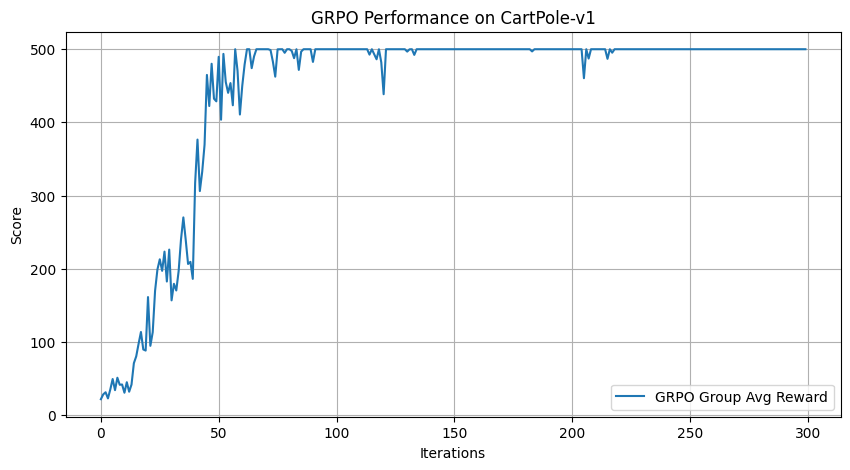

In [5]:
# 开始训练并绘制结果
rewards = train_grpo_gym("CartPole-v1", num_iterations=300, group_size=8)

plt.figure(figsize=(10, 5))
plt.plot(rewards, label='GRPO Group Avg Reward')
plt.xlabel('Iterations')
plt.ylabel('Score')
plt.title('GRPO Performance on CartPole-v1')
plt.legend()
plt.grid()
plt.show()